# Data Exploration and Preparation

## Dataset 1: COVID-19 Frequently Asked Questions (FAQ)

[Dataset1](https://www.kaggle.com/datasets/narendrageek/covid19-frequent-asked-questions)

### Data Description

#### **Dataset Origin**

The COVID-19 Frequently Asked Questions dataset is publicly available on Kaggle and was curated to capture common public queries about COVID-19, reflecting widespread concerns during the pandemic. The dataset focuses on non-clinical, public-facing questions, making it especially relevant for health information dissemination rather than medical diagnosis.

#### **Dataset Structure**

- Total records: 67 question–answer pairs
- Total attributes: 2
- questions: Natural language questions asked by the general public
- answers: Corresponding explanatory answers related to COVID-19

The dataset is fully textual, concise, and well-structured, which makes it suitable for direct ingestion into a Retrieval-Augmented Generation (RAG) pipeline without extensive restructuring.

#### **Nature of the Content**

The questions primarily cover:
- COVID-19 transmission mechanisms
- Symptoms and preventive measures
- Virus survival characteristics
- Vaccine-related concerns

The answers are descriptive and explanatory, typically written in simple language suitable for a lay audience.

#### **Appropriateness for This Study**

This dataset is particularly appropriate because:
- It reflects real-world public health FAQs
- It aligns with your research focus on COVID-19 public health communication
- It is ideal for evaluating retrieval accuracy, grounding, and hallucination reduction
- It supports the study’s objective of generating readable and trustworthy answers for non-expert users

### Statistical & Exploratory Analysis

In [ ]:
# Import Required Libraries

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from typing import List, Dict

In [ ]:
file_path1 = "/content/drive/MyDrive/MS-LJMU/Data/covid19-faq/COVID19_FAQ.csv"

In [ ]:
df1 = pd.read_csv(file_path1)

In [ ]:
df1.head()

,questions,answers
0,1. How does COVID-19 spread?,People can catch COVID-19 from others who have...
1,2. What are the symptoms of COVID-19?,The most common symptoms of COVID-19 are fever...
2,3. How do I know if it is COVID-19 or just the...,A COVID-19 infection has the same signs and sy...
3,4. Can the virus that causes COVID-19 be trans...,Studies to date suggest that the virus that ca...
4,5. What can I do to protect myself and prevent...,Protection measures for everyone Stay aware ...


In [ ]:
# Basic Dataset Inspection

print("Dataset Shape:", df1.shape)

print("Columns:", df1.columns.tolist())

df1.isnull().sum()

Dataset Shape: (67, 2)
Columns: ['questions', 'answers']


,0
questions,0
answers,0


In [ ]:
# Text Length Feature Engineering

# Word counts for questions and answers
df1["question_length"] = df1["questions"].astype(str).apply(lambda x: len(x.split()))
df1["answer_length"] = df1["answers"].astype(str).apply(lambda x: len(x.split()))

df1[["questions", "question_length", "answers", "answer_length"]].head()

,questions,question_length,answers,answer_length
0,1. How does COVID-19 spread?,5,People can catch COVID-19 from others who have...,107
1,2. What are the symptoms of COVID-19?,7,The most common symptoms of COVID-19 are fever...,111
2,3. How do I know if it is COVID-19 or just the...,14,A COVID-19 infection has the same signs and sy...,103
3,4. Can the virus that causes COVID-19 be trans...,12,Studies to date suggest that the virus that ca...,23
4,5. What can I do to protect myself and prevent...,14,Protection measures for everyone Stay aware ...,420


In [ ]:
# Descriptive Statistics

df1[["question_length", "answer_length"]].describe()


,question_length,answer_length
count,67.000000,67.000000
mean,12.910448,84.134328
std,5.594184,59.585664
min,5.000000,18.000000
25%,9.000000,43.500000
50%,12.000000,73.000000
75%,14.500000,106.000000
max,37.000000,420.000000


### Visualisations and Insights

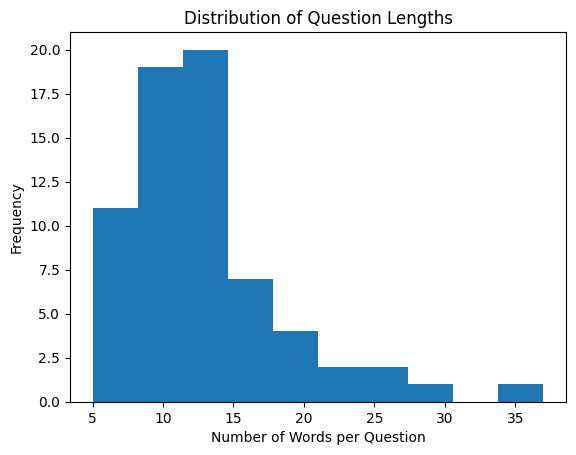

In [ ]:
# Question Length Distribution (Visualization)

plt.figure()
plt.hist(df1["question_length"], bins=10)
plt.title("Distribution of Question Lengths")
plt.xlabel("Number of Words per Question")
plt.ylabel("Frequency")
plt.show()

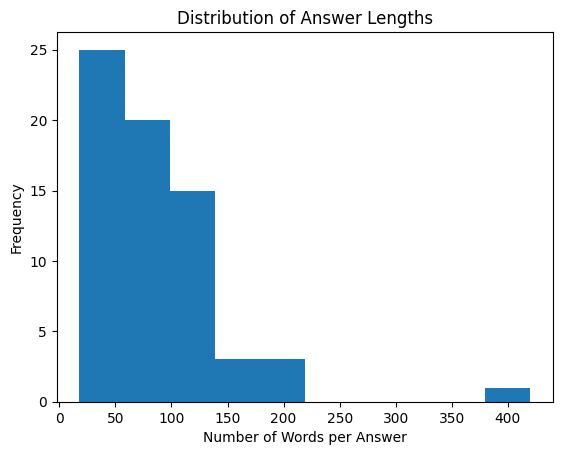

In [ ]:
# Answer Length Distribution (Visualization)

plt.figure()
plt.hist(df1["answer_length"], bins=10)
plt.title("Distribution of Answer Lengths")
plt.xlabel("Number of Words per Answer")
plt.ylabel("Frequency")
plt.show()

In [ ]:
# Identify Very Long Answers (e.g., > 225 words (300 Tokens))

long_answers = df1[df1["answer_length"] > 225]

print("Number of long answers:", long_answers.shape[0])
long_answers[["question_length", "answer_length"]]

Number of long answers: 1


,question_length,answer_length
4,14,420


In [ ]:
# Save Processed Dataset

# df1.to_csv(os.path.join("/content/drive/MyDrive/MS-LJMU/Data/covid19-faq", "COVID19_FAQ_EDA_Processed.csv"), index=False)

# Embedding Preparation

In [ ]:
EMBEDDING_MODEL = "text-embedding-3-large"
EMBEDDING_DIM = 3072

In [ ]:
# !pip install -q tiktoken

In [ ]:
def join_question_answer(question: str, answer: str) -> str:
    """
    Join question and answer in a structured, LLM-friendly format.
    """
    return f"Question: {question.strip()}\n\nAnswer:\n{answer.strip()}"

In [ ]:
df1["joined_text"] = df1.apply(
    lambda row: join_question_answer(row["questions"], row["answers"]),
    axis=1
)

df1[["joined_text"]].head()

,joined_text
0,Question: 1. How does COVID-19 spread?\n\nAnsw...
1,Question: 2. What are the symptoms of COVID-19...
2,Question: 3. How do I know if it is COVID-19 o...
3,Question: 4. Can the virus that causes COVID-1...
4,Question: 5. What can I do to protect myself a...


In [ ]:
def word_count(text: str) -> int:
    return len(text.split())

In [ ]:
def adaptive_chunk_qa(
    question: str,
    answer: str,
    max_words: int = 225 # 300 Tokens
) -> List[str]:
    """
    Adaptive chunking for FAQ-style data.
    If combined Q+A fits within max_words, return single chunk.
    Otherwise, chunk answer only and repeat question.
    """
    combined = join_question_answer(question, answer)

    if word_count(combined) <= max_words:
        return [combined]

    # Chunk answer only
    answer_words = answer.split()
    chunks = []

    for i in range(0, len(answer_words), max_words):
        chunk_answer = " ".join(answer_words[i:i + max_words])
        chunk_text = f"Question: {question.strip()}\n\nAnswer:\n{chunk_answer}"
        chunks.append(chunk_text)

    return chunks

- A helpful rule of thumb is that one token generally corresponds to ~4 characters of text for common English text. This translates to roughly ¾ of a word (so 100 tokens ~= 75 words). [Reference](https://platform.openai.com/tokenizer)

In [ ]:
def prepare_embedding_records(
    df: pd.DataFrame,
    dataset_name: str
) -> List[Dict]:
    """
    Prepare final records for vector database ingestion.
    """
    records = []

    for idx, row in df.iterrows():
        chunks = adaptive_chunk_qa(
            question=row["questions"],
            answer=row["answers"]
        )

        for chunk_id, chunk_text in enumerate(chunks):
            records.append({
                "text": chunk_text,
                "metadata": {
                    "dataset": dataset_name,
                    "original_question": row["questions"],
                    "record_id": idx,
                    "chunk_id": chunk_id,
                    "chunk_type": "full" if len(chunks) == 1 else "partial",
                    "source": "Kaggle COVID-19 FAQ"
                }
            })

    return records

In [ ]:
embedding_records = prepare_embedding_records(
    df=df1,
    dataset_name="COVID19_FAQ"
)

len(embedding_records)

68

In [ ]:
embedding_records

[{'text': 'Question: 1. How does COVID-19 spread?\n\nAnswer:\nPeople can catch COVID-19 from others who have the virus. The disease can spread from person   to person through small droplets from the nose or mouth which are spread when a person with   COVID-19 coughs or exhales. These droplets land on objects and surfaces around the person.   Other people then catch COVID-19 by touching these objects or surfaces, then touching their   eyes, nose or mouth. People can also catch COVID-19 if they breathe in droplets from a person   with COVID-19 who coughs out or exhales droplets. This is why it is important to stay more than   1 meter (3 feet) away from a person who is sick.',
  'metadata': {'dataset': 'COVID19_FAQ',
   'original_question': '1. How does COVID-19 spread?',
   'record_id': 0,
   'chunk_id': 0,
   'chunk_type': 'full',
   'source': 'Kaggle COVID-19 FAQ'}},
 {'text': "Question: 2. What are the symptoms of COVID-19?\n\nAnswer:\nThe most common symptoms of COVID-19 are fever, t